# ¡Hola Pablo! 😊

Mi nombre es **Alejandro Castellanos** y hoy tengo el placer de ser el revisor de tu proyecto.

Voy a revisar todo tu código con detalle, buscando tanto los puntos fuertes como aquellos en los que podrías mejorar. Te dejaré comentarios a lo largo del notebook, destacando lo que has hecho bien y sugiriendo ajustes donde sea necesario. Si encuentro algún error, no te preocupes, te lo haré saber de forma clara y te daré información útil para que puedas corregirlo en la próxima iteración. Si en algún punto tienes comentarios, siéntete libre de dejarlos también.


Encontrarás mis comentarios específicos dentro de cajas verdes, amarillas o rojas, es muy importante que no muevas, modifiques o borres mis comentarios, con el fin de tener un seguimiento adecuado de tu proceso:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

A continuación te dejaré un comentario general con mi valoración del proyecto. **¡Mi objetivo es que sigas aprendiendo y mejorando con cada paso!**


----

<div class="alert alert-block alert-success">
<b>Comentario General del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Pablo, has realizado un trabajo sólido en la exploración inicial de los datos y en el desarrollo del análisis, mostrando un buen manejo de herramientas básicas que te ayudan a comprender la estructura de la información y avanzar con criterio en el proyecto. También se nota que interpretaste adecuadamente los resultados estadísticos y que lograste sustentar una conclusión importante a partir de la prueba aplicada. 

Para seguir fortaleciendo tu trabajo, te conviene cuidar más la claridad visual de algunas gráficas para que la información sea más fácil de leer, y complementar siempre los resultados con una explicación propia que ayude a darles contexto y sentido dentro del análisis. Además, sería valioso revisar algunos supuestos estadísticos antes de aplicar ciertas pruebas, ya que eso puede hacer tus conclusiones más precisas y mejor fundamentadas. 

En definitiva, lograste un equilibrio perfecto entre habilidades técnicas, analíticas y estratégicas.

Éxitos en tu próximo Sprint 🚀

*Estado del Proyecto:* **Aprobado**


</div>

-----

In [1]:
# =============================================================
# PROYECTO ZUBER — Pasos 4 y 5
# Análisis exploratorio de datos y prueba de hipótesis
# =============================================================

import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats


In [2]:
# -------------------------------------------------------------
# PASO 4 — Análisis exploratorio de datos
# -------------------------------------------------------------
 
# 1. Importar los archivos
# -------------------------------------------------------------
df_companies = pd.read_csv('/datasets/project_sql_result_01.csv')
df_dropoffs  = pd.read_csv('/datasets/project_sql_result_04.csv')

In [3]:
# 2. Estudiar los datos
# -------------------------------------------------------------
print('=== Empresas de taxis (result_01) ===')
print(df_companies.head(10))
print(df_companies.info())
print(df_companies.describe())
 
print('\n=== Barrios de finalización (result_04) ===')
print(df_dropoffs.head(10))
print(df_dropoffs.info())
print(df_dropoffs.describe())

=== Empresas de taxis (result_01) ===
                        company_name  trips_amount
0                          Flash Cab         19558
1          Taxi Affiliation Services         11422
2                  Medallion Leasing         10367
3                         Yellow Cab          9888
4    Taxi Affiliation Service Yellow          9299
5          Chicago Carriage Cab Corp          9181
6                       City Service          8448
7                           Sun Taxi          7701
8          Star North Management LLC          7455
9  Blue Ribbon Taxi Association Inc.          5953
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Muy buen trabajo importando las librerías y los datos del proyecto. Adicionalmente usaste correctamente las funciones `info`, `describe` y `head`, esto te permite hacer una primera revisión de los datos, su estructura y contenido.

</div>

In [4]:
# 3. Verificar tipos de datos
# -------------------------------------------------------------
# company_name debe ser string, trips_amount debe ser numérico
print('\nTipos de datos - empresas:', df_companies.dtypes.to_dict())
print('Tipos de datos - barrios:', df_dropoffs.dtypes.to_dict())
 
# Si trips_amount o average_trips no son numéricos, convertir:
df_companies['trips_amount'] = pd.to_numeric(df_companies['trips_amount'])
df_dropoffs['average_trips']  = pd.to_numeric(df_dropoffs['average_trips'])


Tipos de datos - empresas: {'company_name': dtype('O'), 'trips_amount': dtype('int64')}
Tipos de datos - barrios: {'dropoff_location_name': dtype('O'), 'average_trips': dtype('float64')}


In [5]:
# 4. Top 10 barrios por número de finalizaciones
# -------------------------------------------------------------
top10_dropoffs = (df_dropoffs
                  .sort_values('average_trips', ascending=False)
                  .head(10))
 
print('\n=== Top 10 barrios de finalización ===')
print(top10_dropoffs)


=== Top 10 barrios de finalización ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


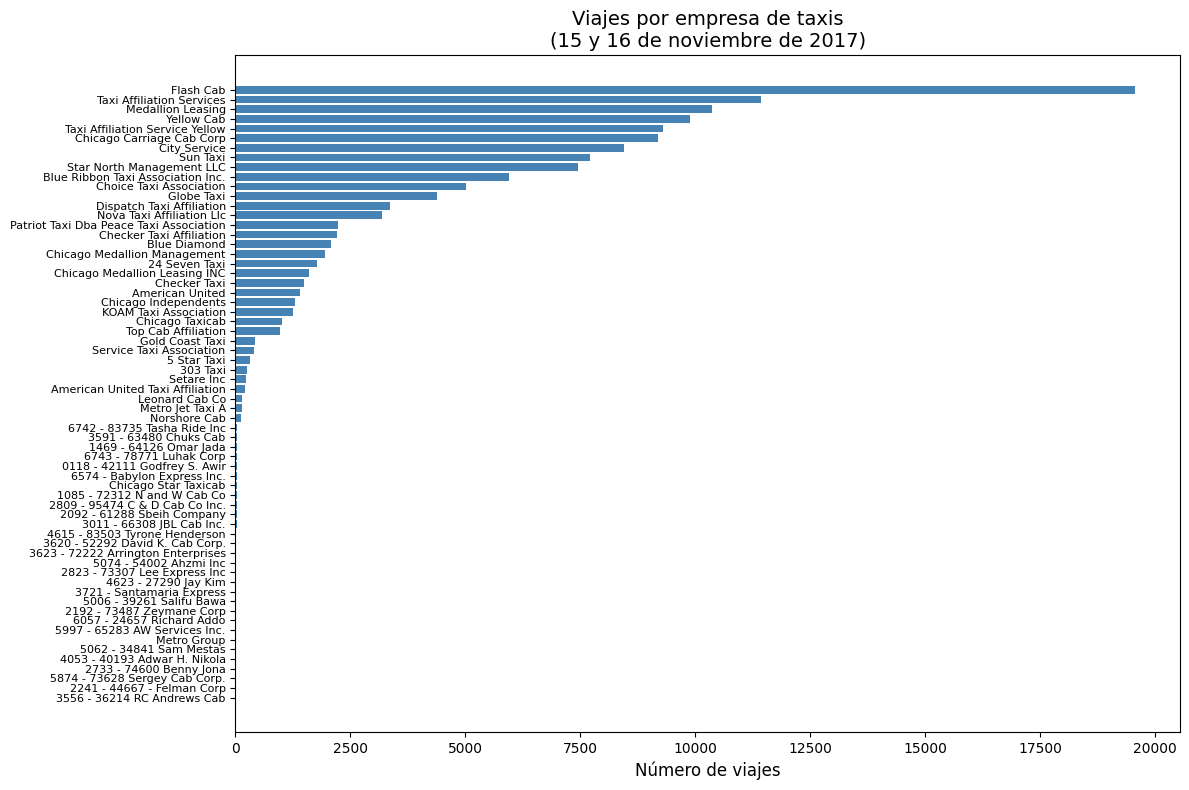

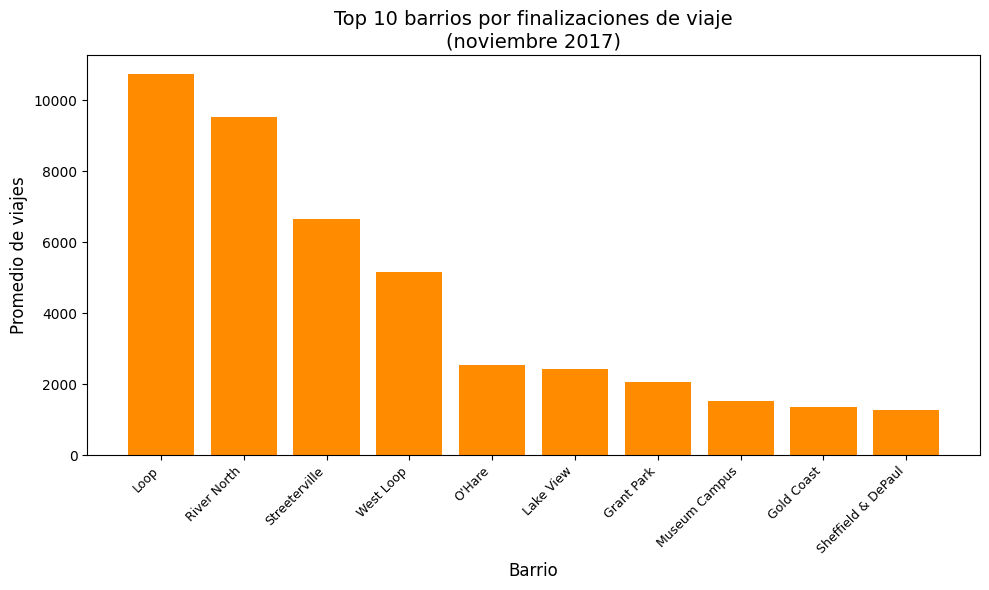

In [6]:
# 5. Gráfico 1 — Empresas de taxis y número de viajes
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 8))
 
df_sorted = df_companies.sort_values('trips_amount', ascending=True)
 
ax.barh(df_sorted['company_name'], df_sorted['trips_amount'], color='steelblue')
ax.set_xlabel('Número de viajes', fontsize=12)
ax.set_title('Viajes por empresa de taxis\n(15 y 16 de noviembre de 2017)', fontsize=14)
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('grafico_empresas.png', dpi=150)
plt.show()
 
# Conclusión gráfico 1:
# El mercado está muy concentrado: Flash Cab y Taxi Affiliation Services
# encabezan ampliamente el ranking. La gran mayoría de empresas tiene
# volúmenes muy bajos, lo que sugiere que Zuber competirá principalmente
# contra dos o tres actores dominantes.
 
# 6. Gráfico 2 — Top 10 barrios por número de finalizaciones
# -------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))
 
ax.bar(top10_dropoffs['dropoff_location_name'],
       top10_dropoffs['average_trips'],
       color='darkorange')
ax.set_xlabel('Barrio', fontsize=12)
ax.set_ylabel('Promedio de viajes', fontsize=12)
ax.set_title('Top 10 barrios por finalizaciones de viaje\n(noviembre 2017)', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('grafico_barrios.png', dpi=150)
plt.show()
 
# Conclusión gráfico 2:
# El Loop concentra la mayor cantidad de finalizaciones, seguido por
# River North y Streeterville. Estos barrios corresponden al centro
# de negocios y zonas turísticas de Chicago, lo que indica que la
# demanda se concentra geográficamente. Zuber debería priorizar
# disponibilidad de vehículos en estas zonas.

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Como recomendación para la primera figura, puedes configurar la gráfica para solo mostrar las principales de empresas, ya que si te das cuenta no es muy clara la lectura de los nombres. Siempre debes asegurarte de que la forma que usas para presentar los datos sea legible, esto facilitará el análisis e interpretación de la información.

Por otro lado, las gráficas que has obtenido son correctas, pero es crucial acompañarlas con tu análisis y observaciones. Esto añade valor significativo a la información presentada y evita que solo sean datos sin contexto. Desarrollar esta capacidad de interpretación es esencial cuanto estamos trabajando con datos en entornos empresariales.

</div>

In [7]:
# -------------------------------------------------------------
# PASO 5 — Prueba de hipótesis
# -------------------------------------------------------------
 
# Importar datos
df_trips = pd.read_csv('/datasets/project_sql_result_07.csv')
 
print('\n=== Viajes Loop → O\'Hare (result_07) ===')
print(df_trips.head())
print(df_trips.info())
print(df_trips['weather_conditions'].value_counts())
 
# Separar los dos grupos
good_weather = df_trips.loc[df_trips['weather_conditions'] == 'Good', 'duration_seconds']
bad_weather  = df_trips.loc[df_trips['weather_conditions'] == 'Bad',  'duration_seconds']
 
print(f'\nViajes con buen clima:  {len(good_weather)}')
print(f'Viajes con mal clima:   {len(bad_weather)}')
print(f'\nDuración promedio (Good): {good_weather.mean():.0f} s')
print(f'Duración promedio (Bad):  {bad_weather.mean():.0f} s')
 
# Planteamiento de hipótesis
# -------------------------------------------------------------
# H0 (nula):       La duración promedio de los viajes los sábados con
#                  lluvia/tormenta es IGUAL a la duración con buen clima.
#                  μ_bad == μ_good
#
# H1 (alternativa): La duración promedio de los viajes los sábados con
#                   lluvia/tormenta es diferente a la de buen clima.
#                   μ_bad ≠ μ_good  (prueba bilateral)
#
# Nivel de significación: α = 0.05
# Si p-value < 0.05 → rechazamos H0
 
# Criterio: prueba t de Welch (scipy.stats.ttest_ind, equal_var=False)
# Se elige esta prueba porque:
#   - Compara las medias de dos grupos independientes.
#   - La variante de Welch no asume que ambos grupos tienen la misma
#     varianza, lo cual es más robusto cuando los tamaños de muestra
#     o dispersiones pueden diferir.
#   - La duración en segundos es una variable continua, lo que hace
#     la prueba t apropiada.
 
alpha = 0.05
 
t_stat, p_value = stats.ttest_ind(bad_weather, good_weather, equal_var=False)
 
print(f'\nEstadístico t: {t_stat:.4f}')
print(f'p-value:       {p_value:.4f}')
print(f'Alfa:          {alpha}')
 
if p_value < alpha:
    print('\nResultado: RECHAZAMOS H0.')
    print('Hay evidencia estadística de que la duración promedio de los viajes')
    print('cambia los sábados lluviosos.')
else:
    print('\nResultado: NO RECHAZAMOS H0.')
    print('No hay evidencia estadística suficiente para afirmar que la duración')
    print('promedio cambia los sábados lluviosos.')


=== Viajes Loop → O'Hare (result_07) ===
              start_ts weather_conditions  duration_seconds
0  2017-11-25 16:00:00               Good            2410.0
1  2017-11-25 14:00:00               Good            1920.0
2  2017-11-25 12:00:00               Good            1543.0
3  2017-11-04 10:00:00               Good            2512.0
4  2017-11-11 07:00:00               Good            1440.0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1068 entries, 0 to 1067
Data columns (total 3 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   start_ts            1068 non-null   object 
 1   weather_conditions  1068 non-null   object 
 2   duration_seconds    1068 non-null   float64
dtypes: float64(1), object(2)
memory usage: 25.2+ KB
None
Good    888
Bad     180
Name: weather_conditions, dtype: int64

Viajes con buen clima:  888
Viajes con mal clima:   180

Duración promedio (Good): 2000 s
Duración promedio (Bad):  2427 s

E

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Pablo aplicaste correctamente la prueba de hipótesis comparando la distribución de dos muestras independientes e interpretando de manera acertada el *p-value* obtenido y su relación con la hipótesis nula, logrando comprobar que el clima sí afecta la duración de los viajes en Taxi

<div class="alert alert-block alert-warning">
<b>Comentario del revisor (1ra Iteración)</b> <a class=“tocSkip”></a>

Te recomiendo realizar previamente una prueba de [Levene](https://www.educaopen.com/digital-lab/blog/educacion-digital/prueba-de-levene) para evaluar la igualdad de las varianzas, lo que te permitirá configurar adecuadamente el parámetro **equal_var** en la función `ttest_ind`. Esto te brindará una interpretación más precisa de los resultados además garantizará que la *prueba t* sea estadísticamente válida.

</div>
</div>